In [9]:
# For categorical target

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Example dataset
df = pd.DataFrame({
    "Gender": ["M", "F", "F", "M", "M", "F"],
    "Department": ["IT", "HR", "HR", "IT", "Finance", "Finance"],
    "Education": ["Bachelor", "Master", "PhD", "Bachelor", "Master", "PhD"],
    "Target": [1, 0, 1, 0, 1, 0]  # classification target
})

# -------------------------------
# 1. Cramér’s V (categorical vs categorical)
# -------------------------------
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rcorr = r - (r-1)**2/(n-1)
    kcorr = k - (k-1)**2/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Check pairwise redundancy between categorical features
cat_cols = df.select_dtypes(include="object").columns
print("Cramér’s V between categorical features:\n")
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        score = cramers_v(df[cat_cols[i]], df[cat_cols[j]])
        print(f"{cat_cols[i]} vs {cat_cols[j]}: {score:.3f}")

# -------------------------------
# 2. Chi-square test (categorical feature vs categorical target)
# -------------------------------
print("\nChi-square test with target:\n")
for col in cat_cols:
    contingency = pd.crosstab(df[col], df["Target"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col}: chi2={chi2:.2f}, p-value={p:.4f}")


Cramér’s V between categorical features:

Gender vs Department: 0.577
Gender vs Education: 0.577
Department vs Education: 0.408

Chi-square test with target:

Gender: chi2=0.00, p-value=1.0000
Department: chi2=0.00, p-value=1.0000
Education: chi2=0.00, p-value=1.0000


In [ ]:
# For continous numerical target

In [1]:
import pandas as pd
from scipy.stats import f_oneway, kruskal
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

def drop_weak_categorical_features(df, target_col, alpha=0.05, mi_threshold=0.0, drop=True):
    """
    Detect categorical features with weak relation to numeric target
    using ANOVA, Kruskal-Wallis, and Mutual Information.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with categorical features and numeric target
    target_col : str
        Name of the numeric target column
    alpha : float
        Significance level for ANOVA/Kruskal (default=0.05)
    mi_threshold : float
        Minimum Mutual Information score to keep a feature
    drop : bool
        If True, returns dataframe with weak categorical features dropped

    Returns
    -------
    df_clean : pd.DataFrame
        Cleaned dataframe (if drop=True) or original df (if drop=False)
    dropped : list
        List of categorical features flagged as weak
    results : pd.DataFrame
        Table with ANOVA p-values, Kruskal p-values, and MI scores
    """
    y = df[target_col]
    cat_cols = df.select_dtypes(include="object").columns
    results = []

    dropped = []
    for col in cat_cols:
        groups = [y[df[col] == level] for level in df[col].dropna().unique()]
        if len(groups) > 1:  # skip single-level categories
            try:
                f_stat, p_anova = f_oneway(*groups)
            except:
                p_anova = 1.0
            try:
                h_stat, p_kruskal = kruskal(*groups)
            except:
                p_kruskal = 1.0
        else:
            p_anova, p_kruskal = 1.0, 1.0

        # Mutual Information (requires numeric encoding)
        le = LabelEncoder()
        encoded = le.fit_transform(df[col].astype(str))
        mi_score = mutual_info_regression(encoded.reshape(-1, 1), y, random_state=42)[0]

        results.append({"Feature": col, "ANOVA_p": p_anova, "Kruskal_p": p_kruskal, "MI": mi_score})

        if (p_anova > alpha) and (p_kruskal > alpha) and (mi_score <= mi_threshold):
            dropped.append(col)

    results_df = pd.DataFrame(results)

    if drop:
        df_clean = df.drop(columns=dropped)
    else:
        df_clean = df.copy()

    return df_clean, dropped, results_df


In [2]:
# Example dataset
df = pd.DataFrame({
    "Gender": ["M", "F", "F", "M", "M", "F"],
    "Department": ["IT", "HR", "HR", "IT", "Finance", "Finance"],
    "Education": ["Bachelor", "Master", "PhD", "Bachelor", "Master", "PhD"],
    "Target": [40000, 42000, 45000, 47000, 50000, 52000]  # numeric regression target
})

df_clean, dropped, results = drop_weak_categorical_features(df, target_col="Target")

print("Dropped features:", dropped)
print("\nResults table:\n", results)
print("\nCleaned DataFrame:\n", df_clean)


Dropped features: ['Gender', 'Education']

Results table:
       Feature   ANOVA_p  Kruskal_p        MI
0      Gender  0.881292   0.827259  0.000000
1  Department  0.158155   0.180092  0.102778
2   Education  0.667988   0.564718  0.000000

Cleaned DataFrame:
   Department  Target
0         IT   40000
1         HR   42000
2         HR   45000
3         IT   47000
4    Finance   50000
5    Finance   52000


In [3]:
df.head()

,Gender,Department,Education,Target
0,M,IT,Bachelor,40000
1,F,HR,Master,42000
2,F,HR,PhD,45000
3,M,IT,Bachelor,47000
4,M,Finance,Master,50000


In [8]:
df_clean.head()

,Department,Target
0,IT,40000
1,HR,42000
2,HR,45000
3,IT,47000
4,Finance,50000


📊 Scikit-learn results:
Intercept: 1.9333
Coefficient: 1.0485
MSE: 0.1406
RMSE: 0.3750
R-squared: 0.9847

📈 Statsmodels summary:
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     516.0
Date:                Tue, 23 Sep 2025   Prob (F-statistic):           1.49e-08
Time:                        15:38:20   Log-Likelihood:                -4.3804
No. Observations:                  10   AIC:                             12.76
Df Residuals:                       8   BIC:                             13.37
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--

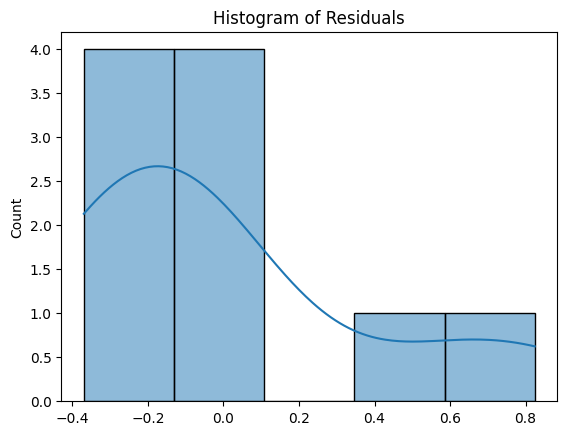

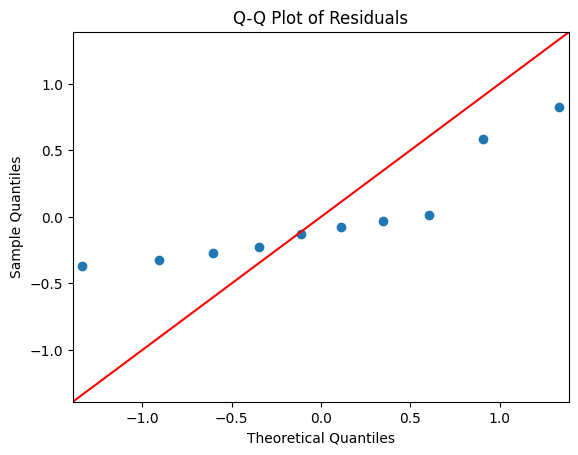

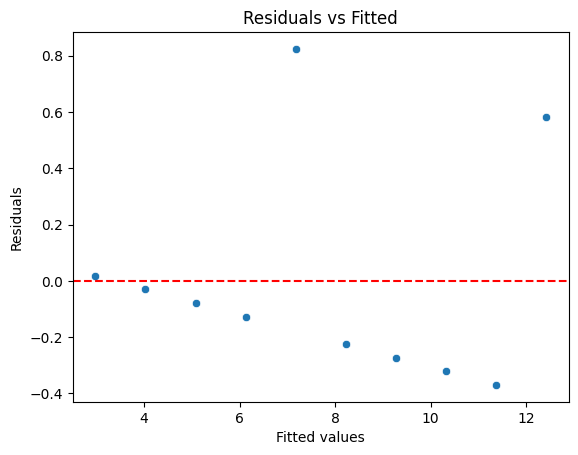

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# ------------------------------
# 1. Example dataset
# ------------------------------
df = pd.DataFrame({
    "X": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Y": [3, 4, 5, 6, 8, 8, 9, 10, 11, 13]
})

X = df[["X"]]   # independent variable
y = df["Y"]     # dependent variable

# ------------------------------
# 2. Fit using sklearn (metrics)
# ------------------------------
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("📊 Scikit-learn results:")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficient: {model.coef_[0]:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

# ------------------------------
# 3. Hypothesis testing (statsmodels)
# ------------------------------
X_const = sm.add_constant(X)  # add intercept
ols_model = sm.OLS(y, X_const).fit()

print("\n📈 Statsmodels summary:")
print(ols_model.summary())

# ------------------------------
# 4. Residual diagnostics
# ------------------------------
residuals = ols_model.resid
fitted = ols_model.fittedvalues

# Histogram of residuals
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.show()

# Q-Q plot
sm.qqplot(residuals, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

# Residuals vs fitted values
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()
